# BEV Fusion - Scene Reconstruction
**ECE228 | Scene Reconstruction for Autonomous Driving**

Combines YOLOv8m object detections with Depth Anything V2 metric depth
to produce bird's-eye-view (BEV) representations of street scenes.

Pipeline per frame:
1. Run YOLOv8m -> bounding boxes (x1, y1, x2, y2) + class ids
2. Run Depth Anything V2 -> dense depth map in metres
3. For each detection, sample depth at the bottom-centre of the box
   (bottom-centre approximates the ground contact point)
4. Use KITTI camera intrinsics K to unproject pixel -> 3D (X, Y, Z)
5. Project 3D points onto a top-down BEV canvas (X horizontal, Z forward)
6. Render side-by-side: RGB + detections | depth map | BEV grid

Runtime requirement: GPU (T4 or better). Runtime > Change runtime type > GPU.

---
## 1. Install Dependencies

In [ ]:
import subprocess, sys

# numpy pin required for ultralytics compatibility (see yolo notebook)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'numpy==1.26.4', '--force-reinstall'],
    check=True
)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'ultralytics>=8.3.225',
     'transformers',
     'accelerate',
     'opencv-python-headless',
     'matplotlib',
     '--upgrade'],
    check=True
)

print('Packages installed.')
print('ACTION REQUIRED: Runtime > Restart session, then continue from Cell 2.')

Packages installed.
ACTION REQUIRED: Runtime > Restart session, then continue from Cell 2.


---
## 2. Configuration

All paths, model IDs, and rendering parameters in one place.
Edit YOLO_CKPT and IMAGE_SOURCE to point to your data.

In [ ]:
# ---------------------------------------------------------------------------
# Model paths
# ---------------------------------------------------------------------------
YOLO_CKPT    = '/content/drive/MyDrive/ECE228_SceneRecon/checkpoints/yolov8m_kitti/weights/best.pt'
DEPTH_MODEL  = 'depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf'

# ---------------------------------------------------------------------------
# Image source
# Set to a directory to process multiple images, or a single .png path.
# ---------------------------------------------------------------------------
IMAGE_SOURCE = '/content/datasets/images/val'
NUM_SAMPLES  = 8     # number of images to process (None = all)

# ---------------------------------------------------------------------------
# Output
# ---------------------------------------------------------------------------
DRIVE_OUT_DIR = '/content/drive/MyDrive/ECE228_SceneRecon/bev_outputs'
LOCAL_OUT_DIR = '/content/bev_outputs'

# ---------------------------------------------------------------------------
# Inference thresholds
# ---------------------------------------------------------------------------
YOLO_CONF    = 0.30
YOLO_IOU     = 0.45
DEPTH_MAX_M  = 80.0   # clip depth beyond this range (metres)
DEPTH_MIN_M  = 1.0    # ignore detections closer than this (metres)

# ---------------------------------------------------------------------------
# KITTI camera intrinsics
# These are the standard KITTI camera_2 (left colour) intrinsics.
# fx, fy: focal lengths in pixels
# cx, cy: principal point in pixels
# Used to unproject 2D pixel + depth -> 3D camera coordinates.
# ---------------------------------------------------------------------------
KITTI_FX = 721.5377
KITTI_FY = 721.5377
KITTI_CX = 609.5593
KITTI_CY = 172.8540

# ---------------------------------------------------------------------------
# BEV canvas parameters
# BEV shows a top-down view: X axis = left/right, Z axis = forward
# ---------------------------------------------------------------------------
BEV_RANGE_Z   = 50.0   # metres forward (depth axis)
BEV_RANGE_X   = 30.0   # metres each side (lateral axis)
BEV_PPM       = 10     # pixels per metre on the BEV canvas

# Derived canvas dimensions
BEV_H = int(BEV_RANGE_Z * BEV_PPM)      # height = forward range
BEV_W = int(BEV_RANGE_X * 2 * BEV_PPM)  # width  = lateral range x2

# ---------------------------------------------------------------------------
# Class definitions
# ---------------------------------------------------------------------------
CLASS_NAMES  = {0: 'Car', 1: 'Pedestrian', 2: 'Cyclist'}

# BGR colours for OpenCV drawing on BEV canvas
CLASS_BGR = {
    0: (235,  99,  37),   # Car        - blue
    1: ( 74, 163,  22),   # Pedestrian - green
    2: (  6, 119, 217),   # Cyclist    - amber
}

# RGB colours for matplotlib (normalised 0-1)
CLASS_RGB = {
    0: (0.145, 0.388, 0.922),
    1: (0.086, 0.639, 0.290),
    2: (0.851, 0.467, 0.024),
}

print('Configuration loaded.')
print(f'  YOLO checkpoint : {YOLO_CKPT}')
print(f'  Depth model     : {DEPTH_MODEL}')
print(f'  Image source    : {IMAGE_SOURCE}')
print(f'  BEV canvas      : {BEV_W} x {BEV_H} px  ({BEV_RANGE_X*2:.0f}m wide x {BEV_RANGE_Z:.0f}m deep)')

Configuration loaded.
  YOLO checkpoint : /content/drive/MyDrive/ECE228_SceneRecon/checkpoints/yolov8m_kitti/weights/best.pt
  Depth model     : depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf
  Image source    : /content/datasets/images/val
  BEV canvas      : 600 x 500 px  (60m wide x 50m deep)


---
## 3. GPU Verification and Drive Mount

In [ ]:
import torch, os
from google.colab import drive

if not torch.cuda.is_available():
    raise RuntimeError(
        'No GPU detected. Go to Runtime > Change runtime type > T4 GPU.'
    )

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'Device  : {torch.cuda.get_device_name(0)}')
print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

drive.mount('/content/drive')

os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
os.makedirs(LOCAL_OUT_DIR, exist_ok=True)

# Download KITTI images if not already present from the YOLO notebook session
if not os.path.exists('/content/datasets/images/val'):
    import zipfile, subprocess
    print('KITTI images not found. Downloading (~372 MB) ...')
    ret = subprocess.run(
        ['wget', '-q', '--show-progress', '--tries=3',
         'https://ultralytics.com/assets/kitti.zip',
         '-O', '/content/kitti.zip'],
        check=False
    )
    if ret.returncode != 0:
        raise RuntimeError('wget failed.')
    os.makedirs('/content/datasets', exist_ok=True)
    with zipfile.ZipFile('/content/kitti.zip', 'r') as z:
        z.extractall('/content/datasets/')
    os.remove('/content/kitti.zip')
    print('KITTI images ready.')
else:
    print('KITTI images already present.')

print(f'Output directory (Drive) : {DRIVE_OUT_DIR}')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
Device  : Tesla T4
VRAM    : 15.6 GB
Mounted at /content/drive
KITTI images not found. Downloading (~372 MB) ...
KITTI images ready.
Output directory (Drive) : /content/drive/MyDrive/ECE228_SceneRecon/bev_outputs


---
## 4. Load Models

Loads both models once and keeps them in memory for batch inference.
YOLOv8m from the fine-tuned checkpoint; Depth Anything V2 from HuggingFace.

In [3]:
import torch
from ultralytics import YOLO
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ------------------------------------------------------------------
# YOLOv8m - fine-tuned on KITTI
# ------------------------------------------------------------------
print(f'Loading YOLO checkpoint: {YOLO_CKPT}')
yolo_model = YOLO(YOLO_CKPT)
print(f'  Parameters : {sum(p.numel() for p in yolo_model.model.parameters()):,}')

# ------------------------------------------------------------------
# Depth Anything V2 Metric Outdoor Small
# Outputs metric depth in metres directly - no scale factor needed.
# ------------------------------------------------------------------
print(f'Loading depth model: {DEPTH_MODEL}')
depth_processor = AutoImageProcessor.from_pretrained(DEPTH_MODEL)
depth_model     = AutoModelForDepthEstimation.from_pretrained(DEPTH_MODEL).to(DEVICE)
depth_model.eval()
print(f'  Depth model loaded on {DEVICE}')

print('Both models ready.')

Creating new Ultralytics Settings v0.0.6 file 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLO checkpoint: /content/drive/MyDrive/ECE228_SceneRecon/checkpoints/yolov8m_kitti/weights/best.pt
  Parameters : 25,858,057
Loading depth model: depth-anything/Depth-Anything-V2-Metric-Outdoor-Small-hf


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

  Depth model loaded on cuda
Both models ready.


---
## 5. Core Inference Functions

Three modular functions:
- `predict_depth`  - runs Depth Anything V2 on a PIL image
- `unproject`      - converts (u, v, depth) to 3D camera coords using K
- `world_to_bev`   - maps 3D point to BEV canvas pixel coordinates

In [4]:
import numpy as np
from PIL import Image

# ------------------------------------------------------------------
# Depth inference
# ------------------------------------------------------------------
@torch.inference_mode()
def predict_depth(pil_image: Image.Image) -> np.ndarray:
    """
    Run Depth Anything V2 on a PIL RGB image.
    Returns a float32 depth map in metres, resized to match input image size.
    """
    inputs  = depth_processor(images=pil_image, return_tensors='pt').to(DEVICE)
    outputs = depth_model(**inputs)
    pred    = outputs.predicted_depth.squeeze().cpu().float().numpy()

    # Resize to original image dimensions
    w, h = pil_image.size
    pred = np.array(
        Image.fromarray(pred).resize((w, h), Image.BILINEAR)
    )
    return pred.clip(0, DEPTH_MAX_M)


# ------------------------------------------------------------------
# Pixel unprojection using camera intrinsics
# ------------------------------------------------------------------
def unproject(u: float, v: float, depth_m: float) -> tuple:
    """
    Convert image pixel (u, v) and metric depth to 3D camera coordinates.

    Camera coordinate system (standard KITTI convention):
      X = right
      Y = down
      Z = forward (depth)

    Args:
        u       : pixel column
        v       : pixel row
        depth_m : depth in metres

    Returns:
        (X, Y, Z) in metres
    """
    X = (u - KITTI_CX) * depth_m / KITTI_FX
    Y = (v - KITTI_CY) * depth_m / KITTI_FY
    Z = depth_m
    return X, Y, Z


# ------------------------------------------------------------------
# 3D point -> BEV canvas pixel
# ------------------------------------------------------------------
def world_to_bev(X: float, Z: float) -> tuple:
    """
    Map 3D camera-frame point (X, Z) to BEV canvas pixel (bev_u, bev_v).

    BEV canvas layout:
      - Origin at bottom-centre of canvas (ego vehicle position)
      - Horizontal axis: X (positive = right)
      - Vertical axis:   Z (positive = upward on canvas = forward in world)

    Returns:
        (bev_u, bev_v) pixel coordinates, or None if outside canvas bounds
    """
    bev_u = int(BEV_W / 2 + X * BEV_PPM)
    bev_v = int(BEV_H     - Z * BEV_PPM)   # flip: larger Z = higher on canvas

    if 0 <= bev_u < BEV_W and 0 <= bev_v < BEV_H:
        return bev_u, bev_v
    return None


print('Inference functions defined.')

Inference functions defined.


---
## 6. BEV Rendering Function

Renders the full BEV canvas for one frame given detections and depth map.
Each detected object is placed as a filled circle at its 3D ground position.
Circle radius is proportional to the physical size of the class.

In [5]:
import cv2
import numpy as np

# Approximate physical radii per class for BEV dot size (metres)
CLASS_RADIUS_M = {0: 1.5, 1: 0.4, 2: 0.6}  # Car, Pedestrian, Cyclist


def render_bev(detections: list) -> np.ndarray:
    """
    Render a BEV canvas from a list of detection dicts.

    Each detection dict must have:
        cls_id  : int
        X       : float  (metres, lateral)
        Z       : float  (metres, forward)
        conf    : float  (detection confidence)

    Returns a BGR uint8 numpy array of shape (BEV_H, BEV_W, 3).
    """
    canvas = np.zeros((BEV_H, BEV_W, 3), dtype=np.uint8)

    # Draw grid lines - one line per 10 metres forward, one per 10 metres lateral
    grid_color = (40, 40, 40)
    for z_m in range(0, int(BEV_RANGE_Z) + 1, 10):
        y_px = int(BEV_H - z_m * BEV_PPM)
        if 0 <= y_px < BEV_H:
            cv2.line(canvas, (0, y_px), (BEV_W, y_px), grid_color, 1)
            cv2.putText(canvas, f'{z_m}m',
                        (2, max(y_px - 2, 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.3, (80, 80, 80), 1)

    for x_m in range(-int(BEV_RANGE_X), int(BEV_RANGE_X) + 1, 10):
        x_px = int(BEV_W / 2 + x_m * BEV_PPM)
        if 0 <= x_px < BEV_W:
            cv2.line(canvas, (x_px, 0), (x_px, BEV_H), grid_color, 1)

    # Draw ego vehicle marker at canvas bottom-centre
    ego_u = BEV_W // 2
    ego_v = BEV_H - 1
    cv2.drawMarker(canvas, (ego_u, ego_v),
                   (255, 255, 255), cv2.MARKER_TRIANGLE_UP, 12, 2)

    # Draw each detected object
    for det in detections:
        cls_id = det['cls_id']
        bev_pt = world_to_bev(det['X'], det['Z'])
        if bev_pt is None:
            continue

        bev_u, bev_v = bev_pt
        color  = CLASS_BGR.get(cls_id, (200, 200, 200))
        radius = max(1, int(CLASS_RADIUS_M.get(cls_id, 1.0) * BEV_PPM))

        cv2.circle(canvas, (bev_u, bev_v), radius, color, -1)   # filled
        cv2.circle(canvas, (bev_u, bev_v), radius, (255,255,255), 1)  # outline

        # Label: first letter of class + depth in metres
        label = f'{CLASS_NAMES.get(cls_id, "?")[0]} {det["Z"]:.0f}m'
        cv2.putText(canvas, label,
                    (bev_u + radius + 1, bev_v + 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.28,
                    color, 1, cv2.LINE_AA)

    return canvas


print('BEV rendering function defined.')

BEV rendering function defined.


---
## 7. Full Pipeline - Process Images

Runs the end-to-end pipeline on NUM_SAMPLES images and saves three outputs
per image: annotated RGB, colourised depth map, and BEV canvas.
Also produces a side-by-side composite figure for each image.

In [6]:
import os, glob, random, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path
from tqdm import tqdm

random.seed(42)

# ------------------------------------------------------------------
# Collect image paths
# ------------------------------------------------------------------
src = Path(IMAGE_SOURCE)
if src.is_file():
    image_paths = [src]
else:
    image_paths = sorted(src.glob('*.png')) + sorted(src.glob('*.jpg'))

if NUM_SAMPLES and len(image_paths) > NUM_SAMPLES:
    image_paths = random.sample(image_paths, NUM_SAMPLES)
    image_paths = sorted(image_paths)

print(f'Processing {len(image_paths)} images ...')

# ------------------------------------------------------------------
# Depth colorisation helper
# ------------------------------------------------------------------
def colorise_depth(depth_map: np.ndarray,
                   vmin: float = 0.0,
                   vmax: float = DEPTH_MAX_M) -> np.ndarray:
    """Convert float depth map to uint8 RGB using plasma colormap."""
    d_norm = np.clip((depth_map - vmin) / (vmax - vmin + 1e-8), 0, 1)
    rgba   = plt.get_cmap('plasma')(d_norm)
    return (rgba[:, :, :3] * 255).astype(np.uint8)


# ------------------------------------------------------------------
# Per-frame statistics accumulator
# ------------------------------------------------------------------
frame_stats = []

# ------------------------------------------------------------------
# Main loop
# ------------------------------------------------------------------
for img_path in tqdm(image_paths, desc='BEV fusion'):
    t0 = time.time()

    # -- Load image ------------------------------------------------
    pil_img  = Image.open(img_path).convert('RGB')
    img_bgr  = cv2.imread(str(img_path))
    img_h, img_w = img_bgr.shape[:2]

    # -- YOLOv8 detection ------------------------------------------
    yolo_results = yolo_model(
        img_bgr,
        conf=YOLO_CONF,
        iou=YOLO_IOU,
        verbose=False
    )[0]

    # -- Depth estimation ------------------------------------------
    depth_map = predict_depth(pil_img)  # float32, metres, shape (H, W)

    # -- Fuse: unproject each detection to 3D ----------------------
    detections = []
    annotated  = img_bgr.copy()

    for box in yolo_results.boxes:
        cls_id          = int(box.cls)
        conf            = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Sample depth at the bottom-centre of the bounding box.
        # Bottom-centre better approximates the object's ground contact
        # point than the box centre, improving BEV placement accuracy.
        sample_u = int((x1 + x2) / 2)
        sample_v = min(y2, img_h - 1)   # clamp to image boundary

        # Average over a small 5x5 patch to reduce single-pixel noise
        u0 = max(0, sample_u - 2)
        u1 = min(img_w, sample_u + 3)
        v0 = max(0, sample_v - 2)
        v1 = min(img_h, sample_v + 3)
        depth_m = float(depth_map[v0:v1, u0:u1].mean())

        # Skip detections with unreliable depth
        if depth_m < DEPTH_MIN_M or depth_m > DEPTH_MAX_M:
            continue

        X, Y, Z = unproject(sample_u, sample_v, depth_m)

        detections.append({
            'cls_id': cls_id,
            'conf'  : conf,
            'X'     : X,
            'Y'     : Y,
            'Z'     : Z,
            'box'   : (x1, y1, x2, y2),
        })

        # Draw annotated box on RGB image
        bgr   = CLASS_BGR.get(cls_id, (200, 200, 200))
        label = f'{CLASS_NAMES.get(cls_id, "?")} {conf:.2f} | {depth_m:.1f}m'
        cv2.rectangle(annotated, (x1, y1), (x2, y2), bgr, 2)
        cv2.rectangle(annotated, (x1, y1 - 14), (x1 + len(label)*7, y1), bgr, -1)
        cv2.putText(annotated, label, (x1 + 2, y1 - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255, 255, 255), 1, cv2.LINE_AA)

    # -- Render BEV ------------------------------------------------
    bev_canvas = render_bev(detections)

    # -- Colourised depth ------------------------------------------
    depth_vis = colorise_depth(depth_map)

    elapsed = time.time() - t0

    # -- Composite figure ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(21, 5),
                              gridspec_kw={'wspace': 0.04})
    fig.suptitle(
        f'{img_path.stem}   |   {len(detections)} detections   |   {elapsed:.2f}s',
        fontsize=12, fontweight='bold'
    )

    # Panel 0: RGB + detections + depth label
    axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title('RGB + Detections (depth labelled)', fontsize=10)
    axes[0].axis('off')

    # Panel 1: depth map
    axes[1].imshow(depth_vis)
    axes[1].set_title(f'Depth Anything V2 (0 - {DEPTH_MAX_M:.0f}m)', fontsize=10)
    axes[1].axis('off')

    # Panel 2: BEV
    axes[2].imshow(cv2.cvtColor(bev_canvas, cv2.COLOR_BGR2RGB),
                   origin='upper',
                   extent=[-BEV_RANGE_X, BEV_RANGE_X, 0, BEV_RANGE_Z])
    axes[2].set_title('Bird\'s-Eye View (top-down)', fontsize=10)
    axes[2].set_xlabel('Lateral X (m)')
    axes[2].set_ylabel('Forward Z (m)')
    axes[2].set_xlim(-BEV_RANGE_X, BEV_RANGE_X)
    axes[2].set_ylim(0, BEV_RANGE_Z)

    # Legend on BEV panel
    legend_patches = [
        mpatches.Patch(color=CLASS_RGB[i], label=CLASS_NAMES[i])
        for i in sorted(CLASS_NAMES)
    ]
    axes[2].legend(handles=legend_patches, loc='upper right',
                   fontsize=8, framealpha=0.7)

    # Save composite
    composite_path = f'{LOCAL_OUT_DIR}/{img_path.stem}_bev.png'
    plt.savefig(composite_path, bbox_inches='tight', dpi=130)
    plt.close(fig)

    # Save individual outputs
    cv2.imwrite(f'{LOCAL_OUT_DIR}/{img_path.stem}_rgb_det.png', annotated)
    cv2.imwrite(f'{LOCAL_OUT_DIR}/{img_path.stem}_depth.png',
                cv2.cvtColor(depth_vis, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f'{LOCAL_OUT_DIR}/{img_path.stem}_bev_only.png', bev_canvas)

    frame_stats.append({
        'frame'     : img_path.stem,
        'n_det'     : len(detections),
        'elapsed_s' : elapsed,
        'detections': detections,
    })

print(f'\nProcessed {len(frame_stats)} frames.')
print(f'Outputs written to {LOCAL_OUT_DIR}/')

Processing 8 images ...


BEV fusion: 100%|##########| 8/8 [00:09<00:00,  1.24s/it]


Processed 8 frames.
Outputs written to /content/bev_outputs/


---
## 8. Display Results

Renders the composite figures inline for all processed frames.

Displaying 8 composite frames:
  000259_bev.png


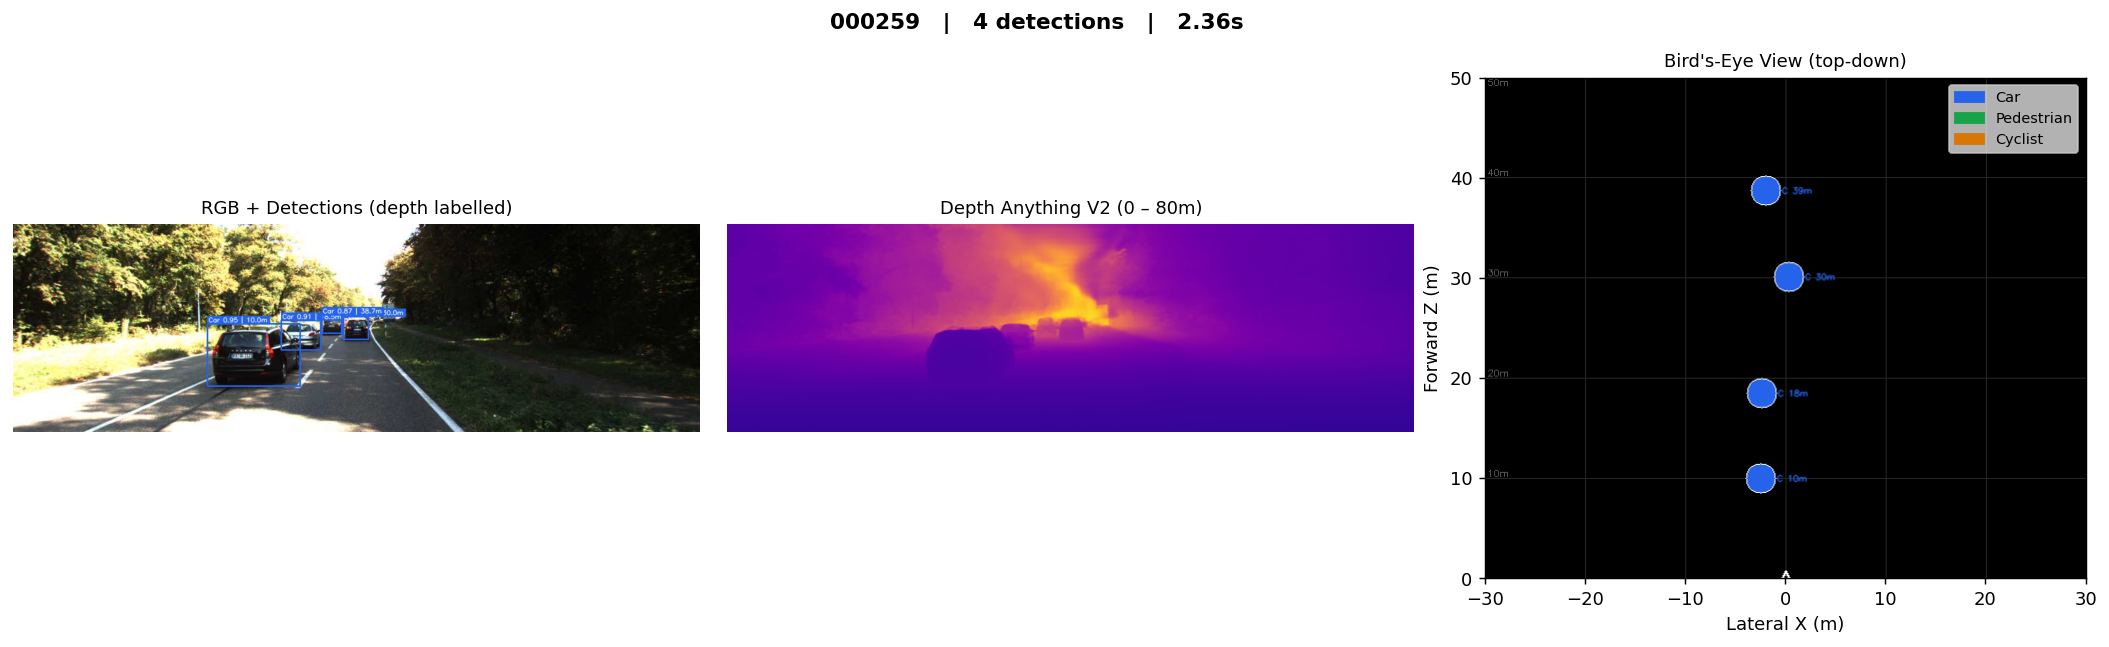

  001115_bev.png


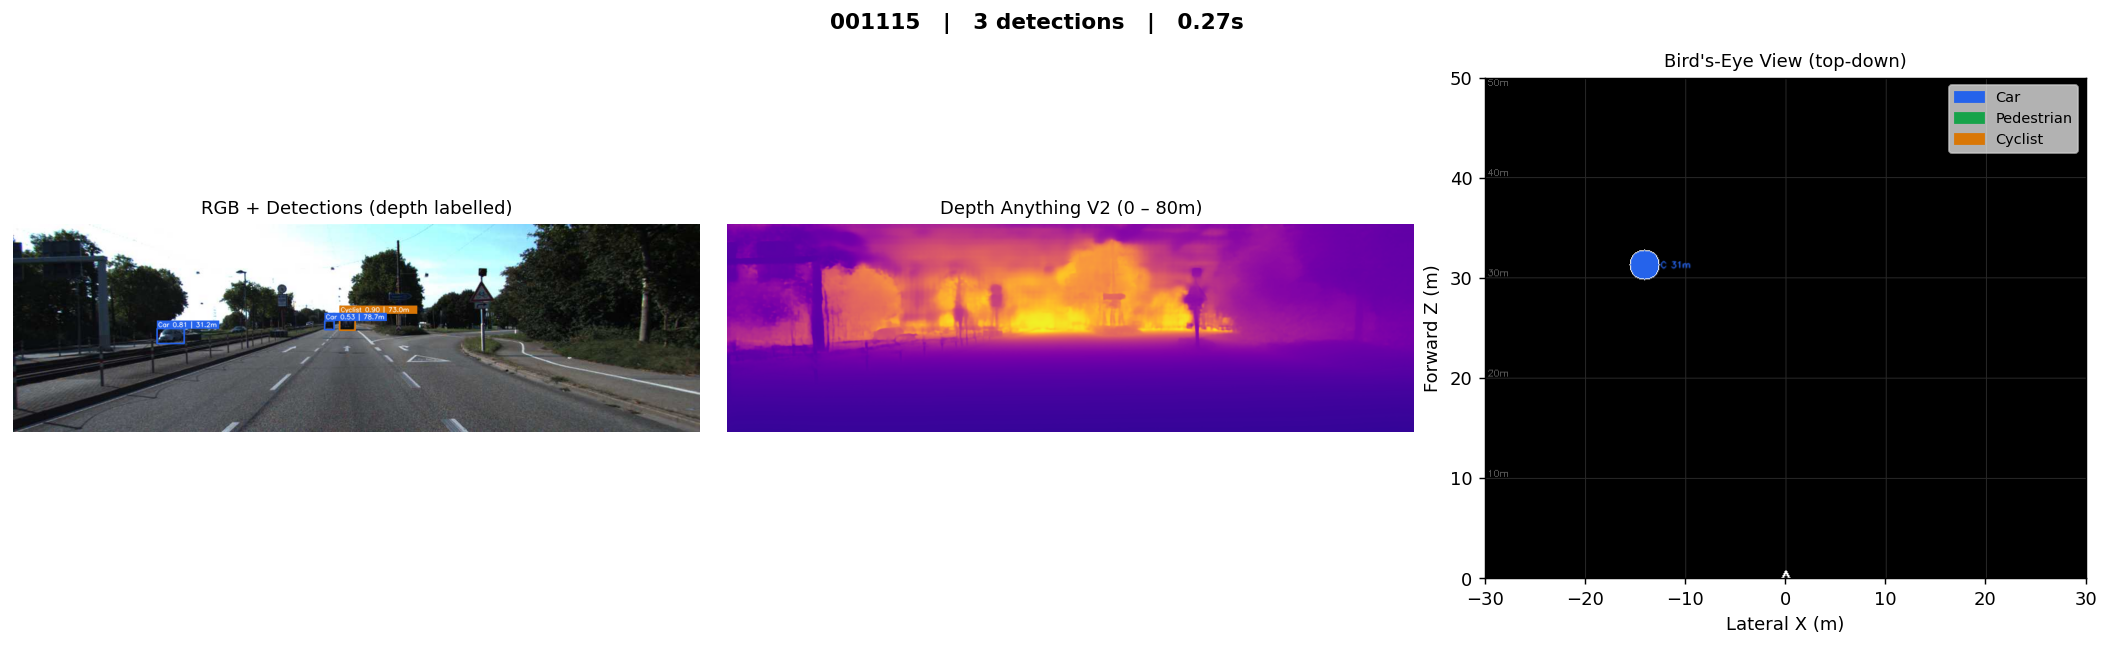

  001213_bev.png


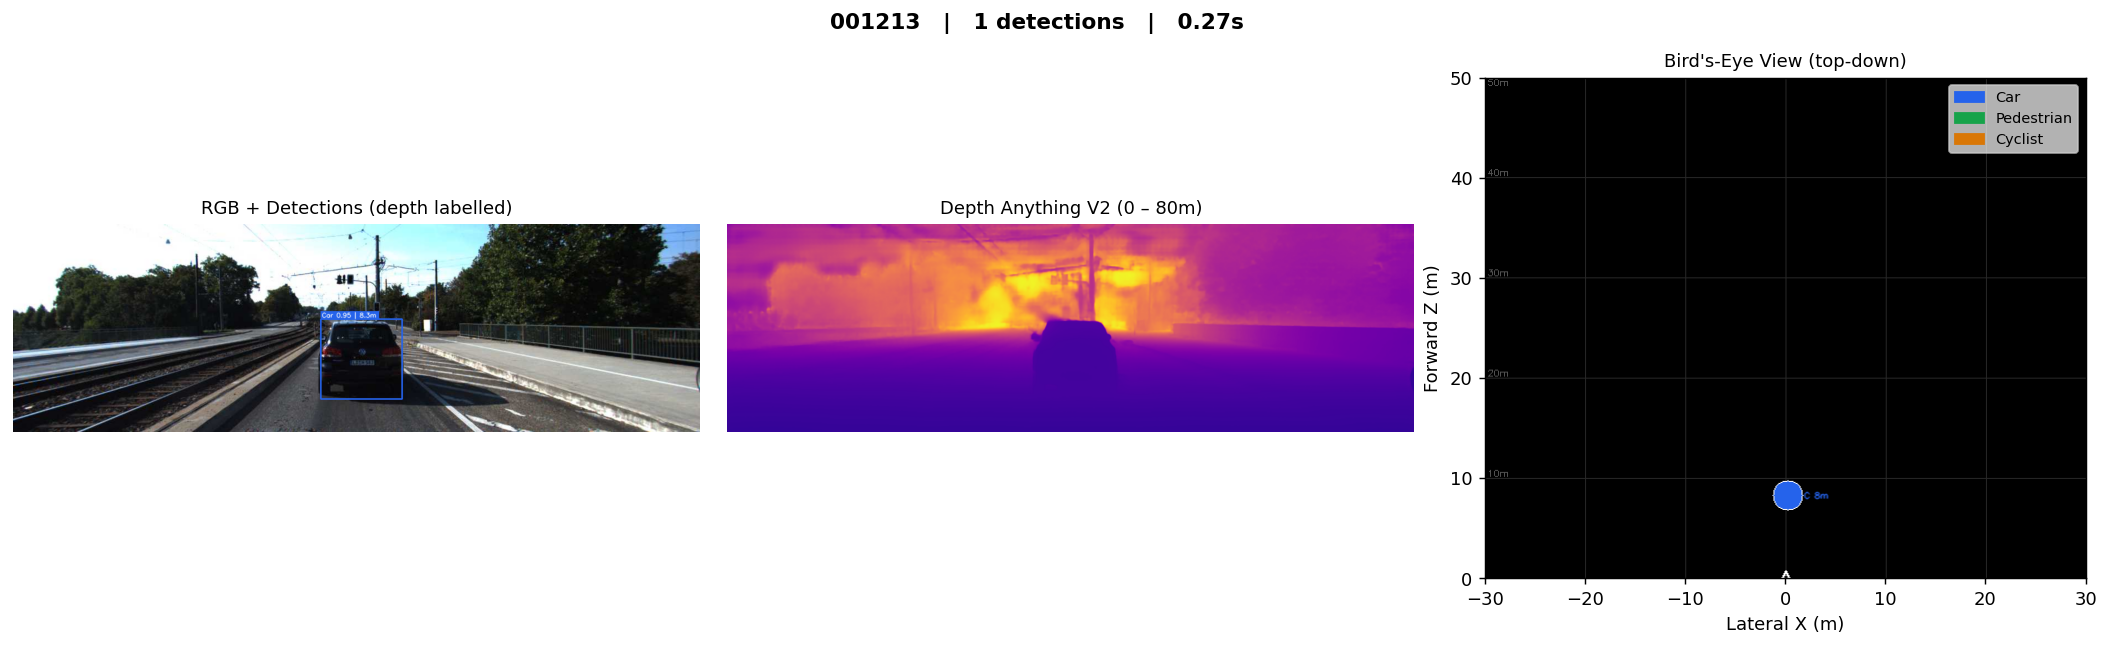

  001524_bev.png


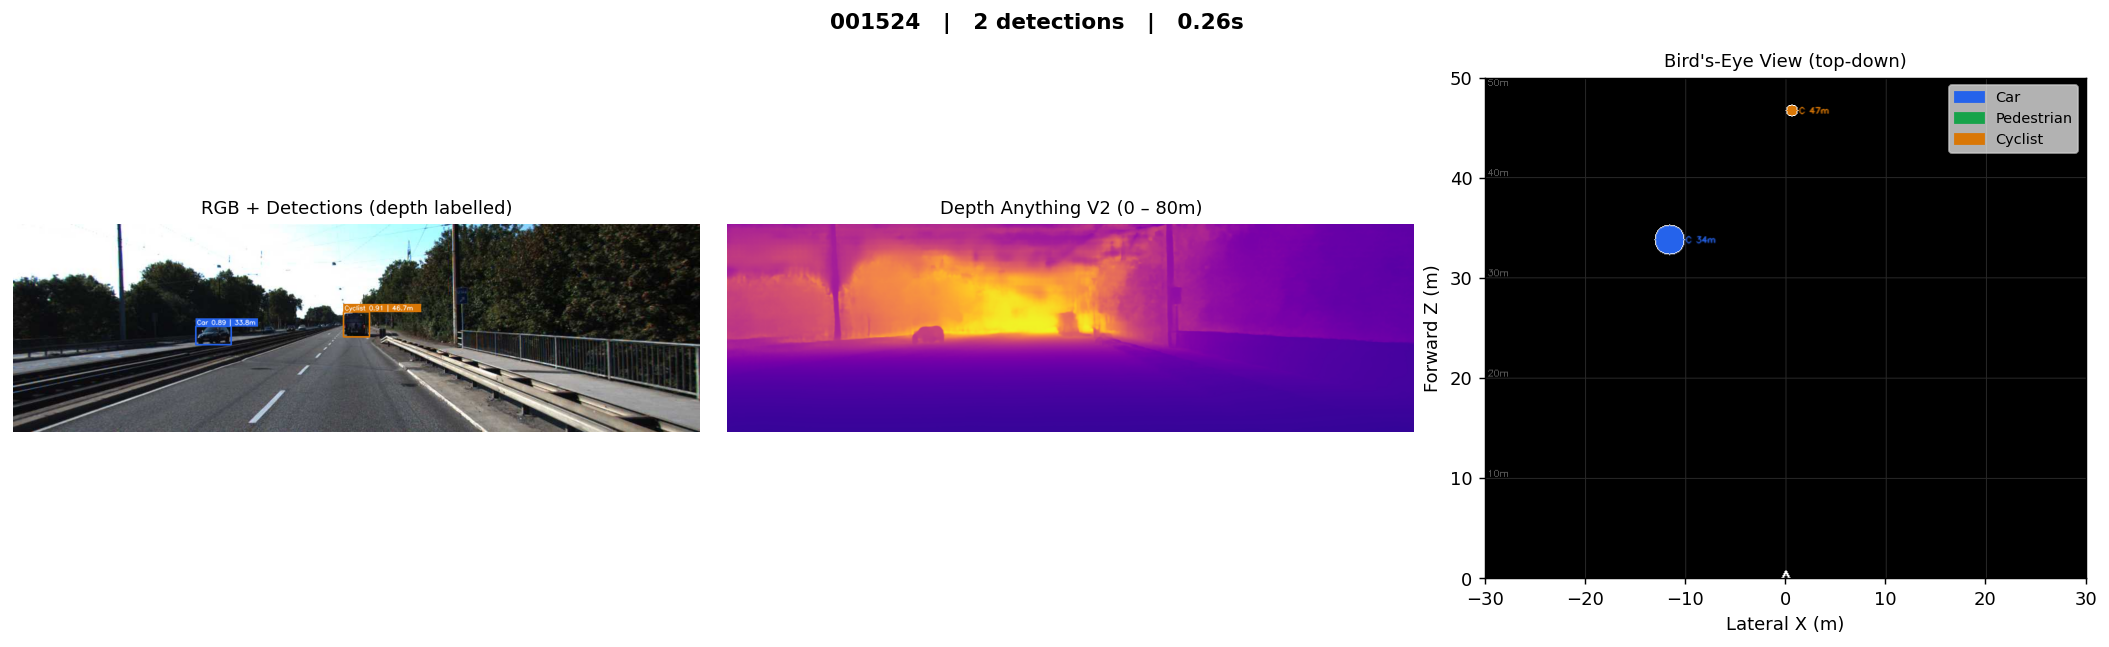

  002334_bev.png


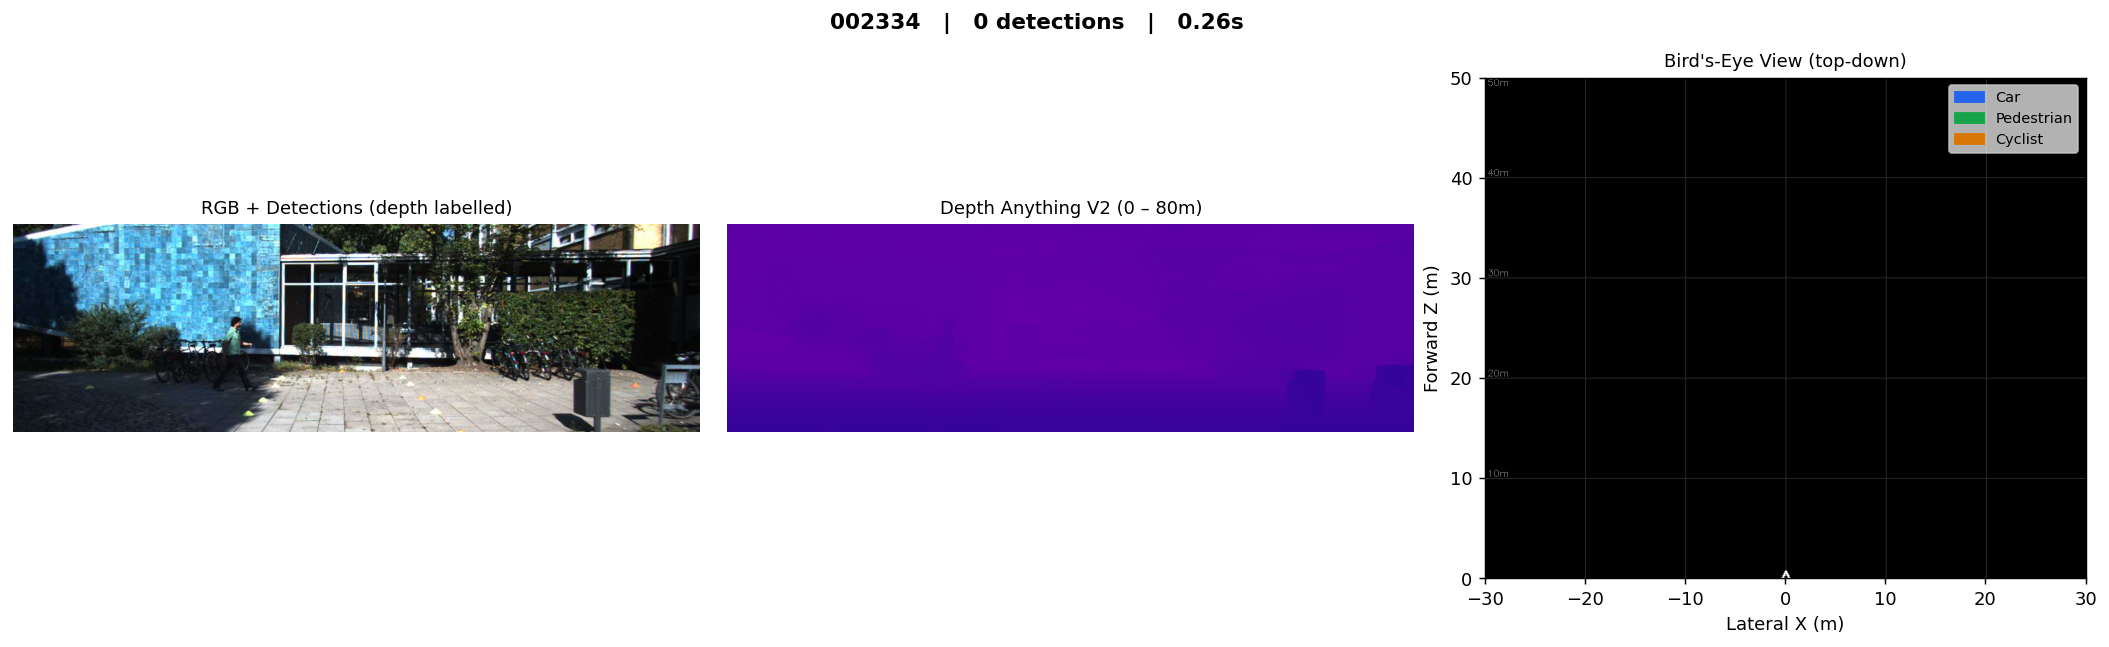

  002561_bev.png


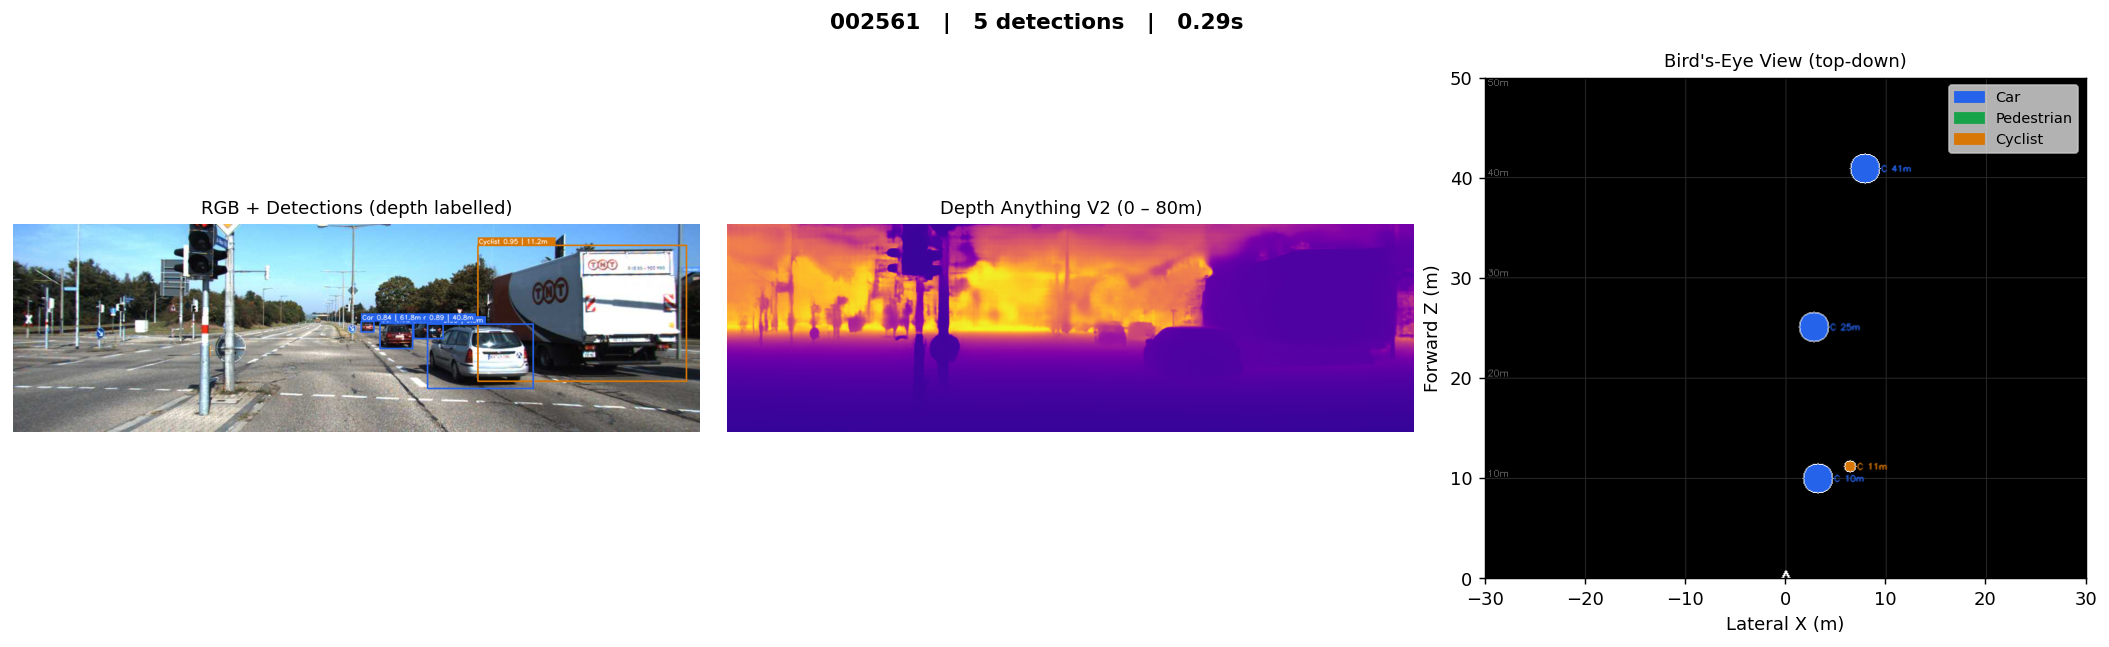

  002812_bev.png


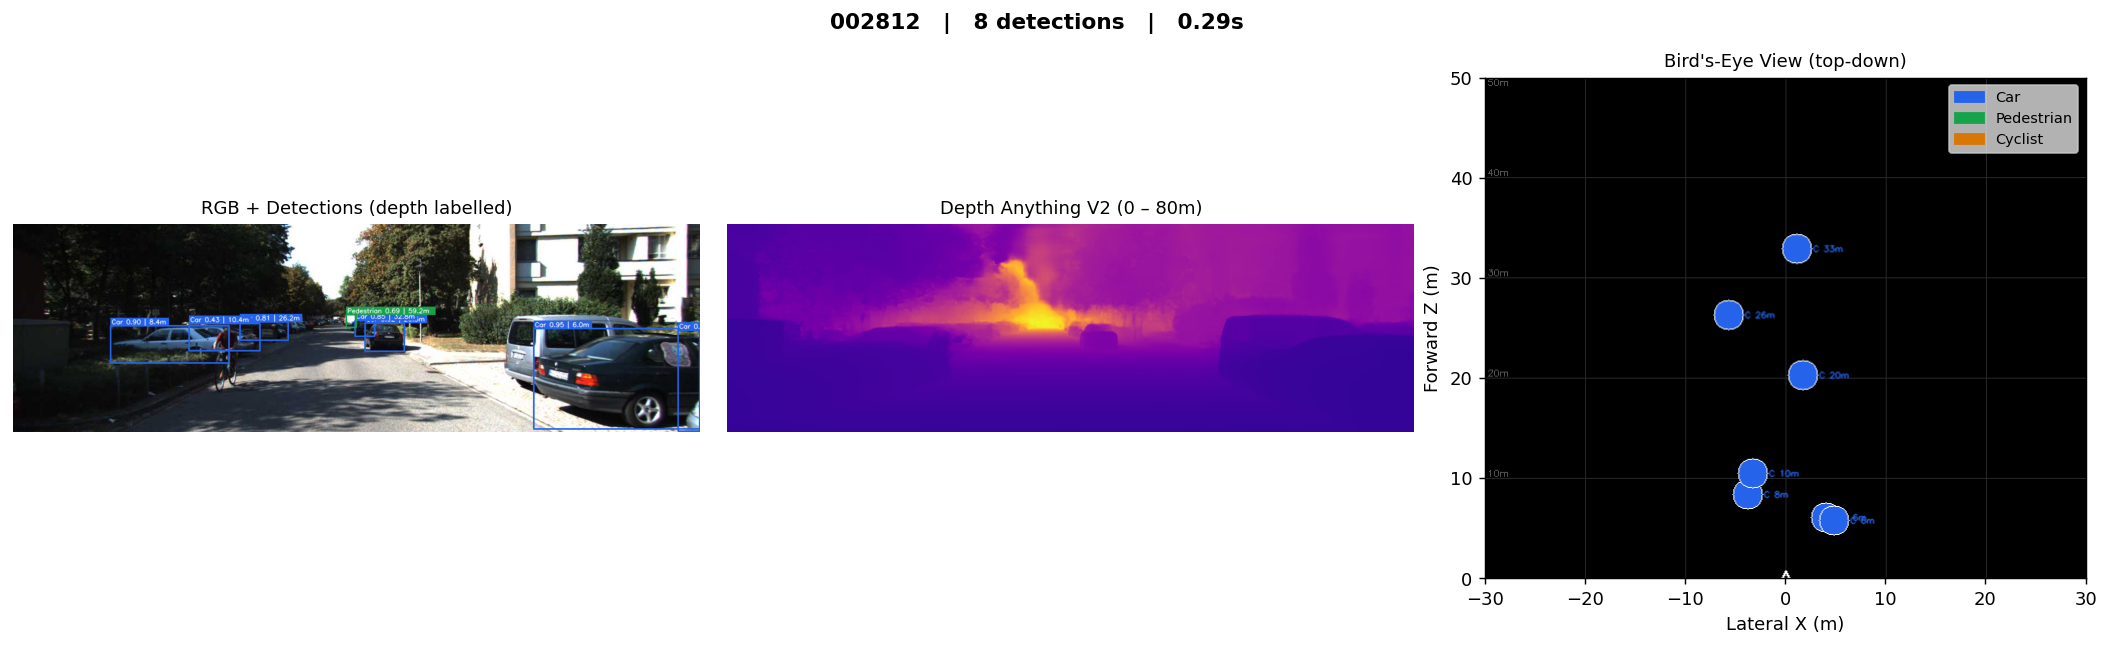

  006468_bev.png


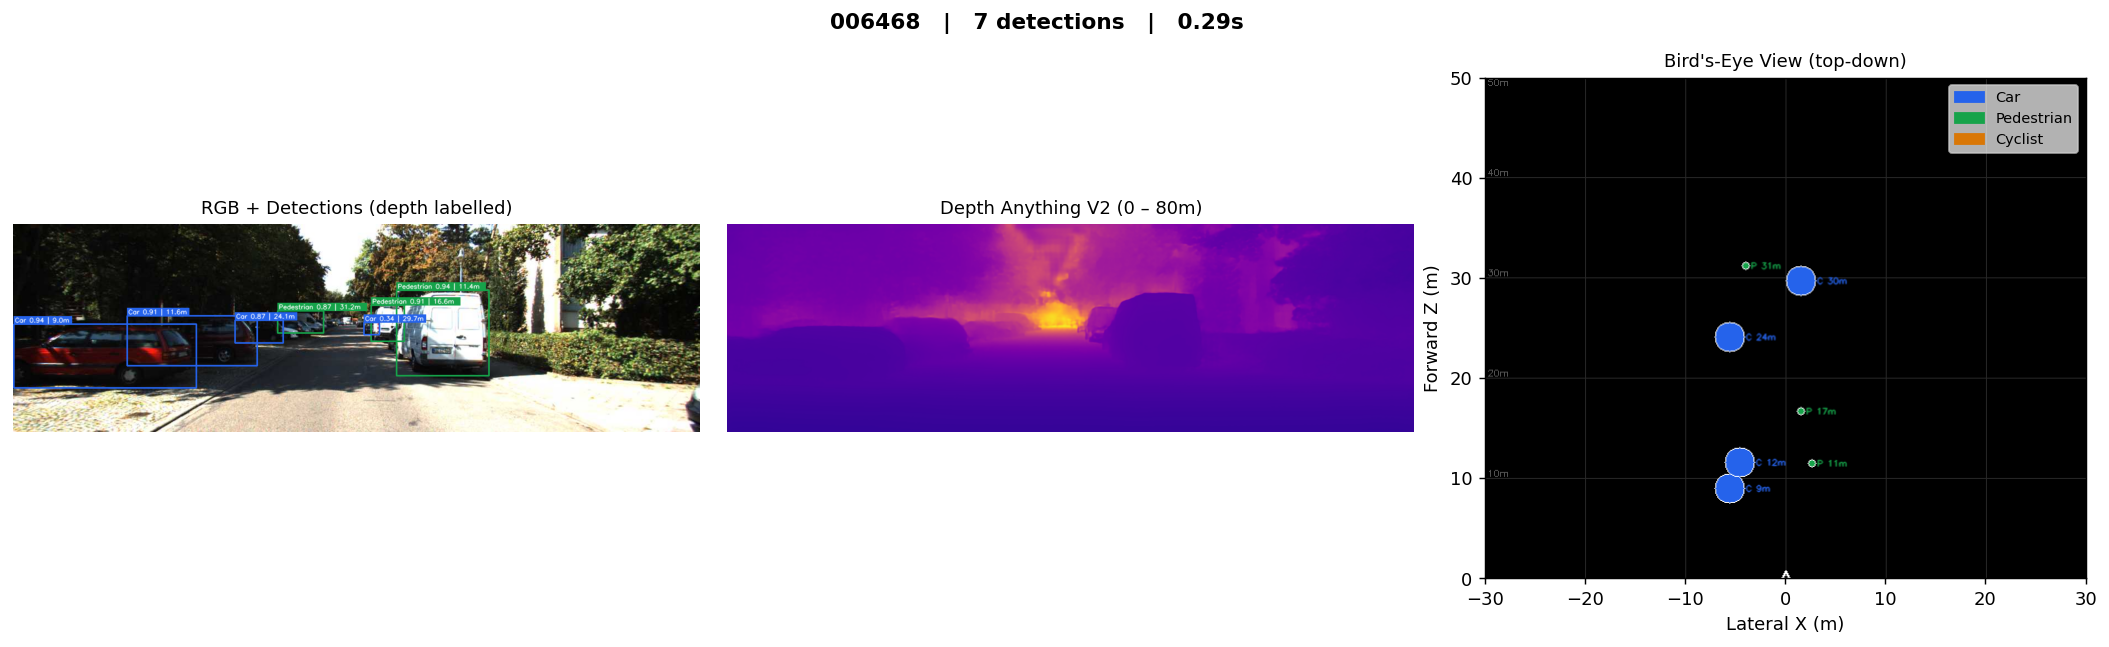

In [7]:
from IPython.display import display, Image as IPImage
import glob as _glob

composite_files = sorted(_glob.glob(f'{LOCAL_OUT_DIR}/*_bev.png'))
print(f'Displaying {len(composite_files)} composite frames:')

for path in composite_files:
    print(f'  {os.path.basename(path)}')
    display(IPImage(path, width=1100))

---
## 9. Per-Frame Statistics

In [8]:
import numpy as np

total_dets = sum(s['n_det'] for s in frame_stats)
avg_time   = np.mean([s['elapsed_s'] for s in frame_stats])

sep = '-' * 60
print(sep)
print('BEV FUSION SUMMARY')
print(sep)
print(f'  Frames processed     : {len(frame_stats)}')
print(f'  Total detections     : {total_dets}')
print(f'  Avg detections/frame : {total_dets / len(frame_stats):.1f}')
print(f'  Avg time/frame       : {avg_time:.2f}s')
print(f'  Effective FPS        : {1/avg_time:.2f}')
print(sep)

# Per-class breakdown
class_counts = {name: 0 for name in CLASS_NAMES.values()}
depth_by_class = {name: [] for name in CLASS_NAMES.values()}

for s in frame_stats:
    for det in s['detections']:
        name = CLASS_NAMES.get(det['cls_id'], 'Unknown')
        class_counts[name]    += 1
        depth_by_class[name].append(det['Z'])

print('  Per-class statistics:')
print(f'  {"Class":<14} {"Count":>7} {"Avg depth (m)":>15} {"Min depth (m)":>15}')
print(f'  {"-"*54}')
for name in CLASS_NAMES.values():
    depths = depth_by_class[name]
    avg_d  = np.mean(depths) if depths else 0.0
    min_d  = np.min(depths)  if depths else 0.0
    print(f'  {name:<14} {class_counts[name]:>7} {avg_d:>15.1f} {min_d:>15.1f}')
print(sep)

print(f'\n  Output directory: {LOCAL_OUT_DIR}')

------------------------------------------------------------
BEV FUSION SUMMARY
------------------------------------------------------------
  Frames processed     : 8
  Total detections     : 30
  Avg detections/frame : 3.8
  Avg time/frame       : 0.54s
  Effective FPS        : 1.87
------------------------------------------------------------
  Per-class statistics:
  Class            Count   Avg depth (m)   Min depth (m)
  ------------------------------------------------------
  Car                 23            24.8             5.7
  Pedestrian           4            29.6            11.4
  Cyclist              3            43.6            11.2
------------------------------------------------------------

  Output directory: /content/bev_outputs


---
## 10. Copy Outputs to Google Drive

In [ ]:
import shutil, os, glob as _glob
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
drive_run  = f'{DRIVE_OUT_DIR}/run_{timestamp}'
os.makedirs(drive_run, exist_ok=True)

files_to_copy = _glob.glob(f'{LOCAL_OUT_DIR}/*.png')
print(f'Copying {len(files_to_copy)} files to {drive_run} ...')

for src_path in sorted(files_to_copy):
    dst_path = f'{drive_run}/{os.path.basename(src_path)}'
    shutil.copy2(src_path, dst_path)
    size_mb = os.path.getsize(dst_path) / 1e6
    print(f'  {os.path.basename(src_path):<50} {size_mb:.1f} MB')

print(f'\nAll outputs saved to {drive_run}')